# Car Price Prediction Model

This notebook uses your provided CSV file to build a car price prediction model, expands features, evaluates with MAE, plots regression, explains coefficients, and discusses web integration.

In [34]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


In [35]:
# Data Loading
# Load the provided CSV file
df = pd.read_csv('car_price_prediction.csv')
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (19237, 18)


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [36]:
# Data Cleaning
# Remove rows with missing or invalid values
df.replace('-', np.nan, inplace=True)
df.dropna(inplace=True)  # Drop all rows with any NaN

# Convert numeric columns
df['Levy'] = pd.to_numeric(df['Levy'])
df['Mileage'] = df['Mileage'].str.replace(' km','').str.replace(',','').astype(float)
df['Engine volume'] = df['Engine volume'].str.extract(r'([\d.]+)').astype(float)
df['Prod. year'] = pd.to_numeric(df['Prod. year'])
df['Cylinders'] = pd.to_numeric(df['Cylinders'])
df['Airbags'] = pd.to_numeric(df['Airbags'])
df['Price'] = pd.to_numeric(df['Price'])

# Encode categorical variables
le_manufacturer = LabelEncoder()
le_model = LabelEncoder()
le_category = LabelEncoder()
le_fuel = LabelEncoder()
le_gear = LabelEncoder()
le_drive = LabelEncoder()
le_wheel = LabelEncoder()
le_color = LabelEncoder()

df['Manufacturer_enc'] = le_manufacturer.fit_transform(df['Manufacturer'])
df['Model_enc'] = le_model.fit_transform(df['Model'])
df['Category_enc'] = le_category.fit_transform(df['Category'])
df['Fuel_enc'] = le_fuel.fit_transform(df['Fuel type'])
df['Gear_enc'] = le_gear.fit_transform(df['Gear box type'])
df['Drive_enc'] = le_drive.fit_transform(df['Drive wheels'])
df['Wheel_enc'] = le_wheel.fit_transform(df['Wheel'])
df['Color_enc'] = le_color.fit_transform(df['Color'])
df['Leather interior'] = df['Leather interior'].map({'Yes':1, 'No':0})

## Exploratory Data Analysis (EDA)

In [37]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 13418 entries, 0 to 19236
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                13418 non-null  int64  
 1   Price             13418 non-null  int64  
 2   Levy              13418 non-null  int64  
 3   Manufacturer      13418 non-null  object 
 4   Model             13418 non-null  object 
 5   Prod. year        13418 non-null  int64  
 6   Category          13418 non-null  object 
 7   Leather interior  13418 non-null  int64  
 8   Fuel type         13418 non-null  object 
 9   Engine volume     13418 non-null  float64
 10  Mileage           13418 non-null  float64
 11  Cylinders         13418 non-null  float64
 12  Gear box type     13418 non-null  object 
 13  Drive wheels      13418 non-null  object 
 14  Doors             13418 non-null  object 
 15  Wheel             13418 non-null  object 
 16  Color             13418 non-nul

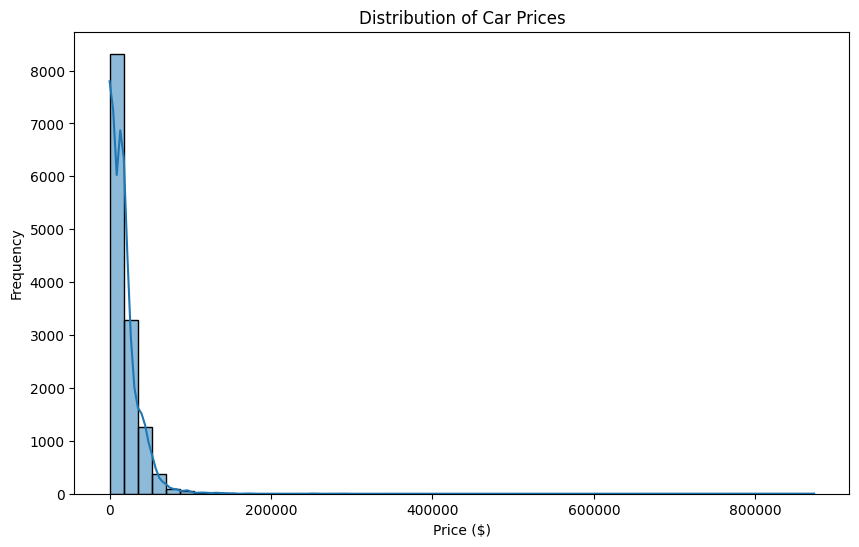

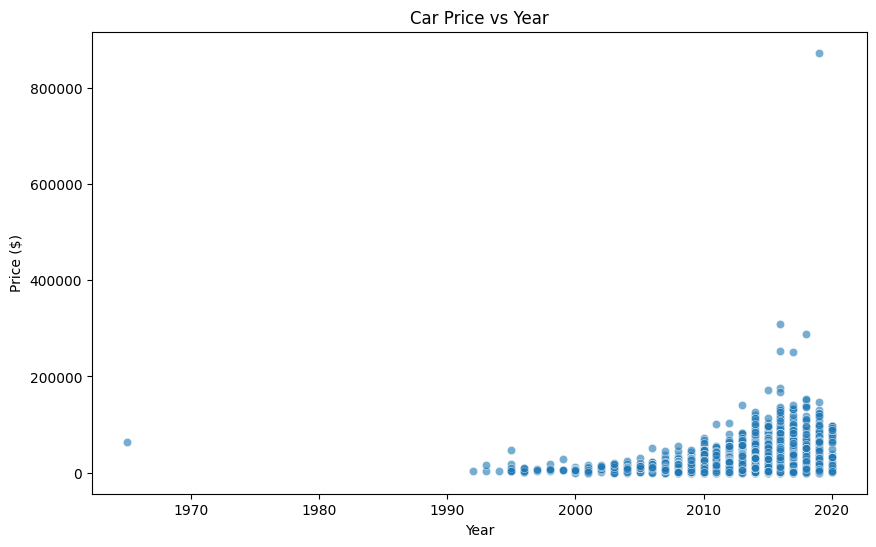

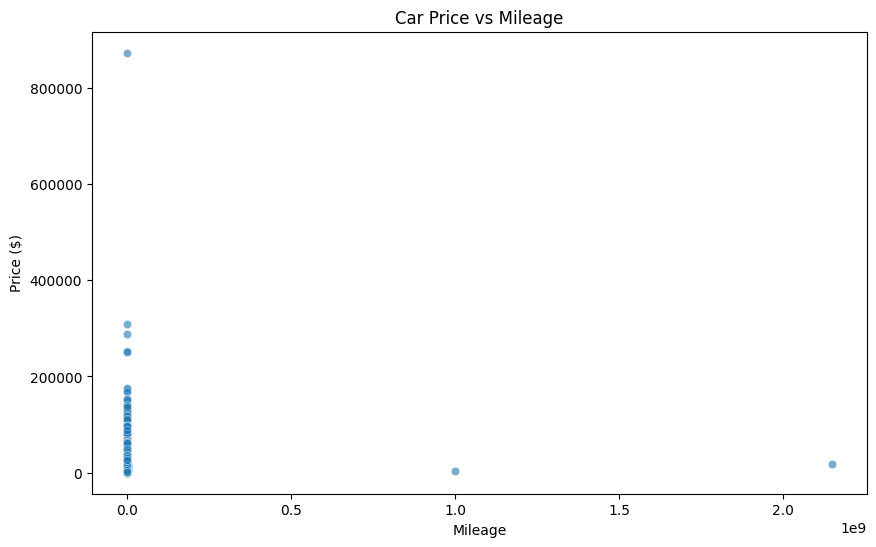

In [38]:
# Visualize the distribution of car prices
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Price vs Year
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Prod. year', y='Price', data=df, alpha=0.6)
plt.title('Car Price vs Year')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.show()

# Price vs Mileage
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Mileage', y='Price', data=df, alpha=0.6)
plt.title('Car Price vs Mileage')
plt.xlabel('Mileage')
plt.ylabel('Price ($)')
plt.show()

## Data Preprocessing

In [39]:
# Select features for the model (expanded)
features = [
    'Levy', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags',
    'Leather interior', 'Manufacturer_enc', 'Model_enc', 'Category_enc',
    'Fuel_enc', 'Gear_enc', 'Drive_enc', 'Wheel_enc', 'Color_enc'
]
target = 'Price'
X = df[features]
y = df[target]
print("Features selected:", features)
print("Target variable:", target)
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features selected: ['Levy', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags', 'Leather interior', 'Manufacturer_enc', 'Model_enc', 'Category_enc', 'Fuel_enc', 'Gear_enc', 'Drive_enc', 'Wheel_enc', 'Color_enc']
Target variable: Price
X shape: (13418, 15), y shape: (13418,)


In [40]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 10734 samples
Test set: 2684 samples


## Model Training

In [41]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_model
print("Model trained successfully!")

Model trained successfully!


## Model Evaluation

Mean Absolute Error (MAE): 11091.82


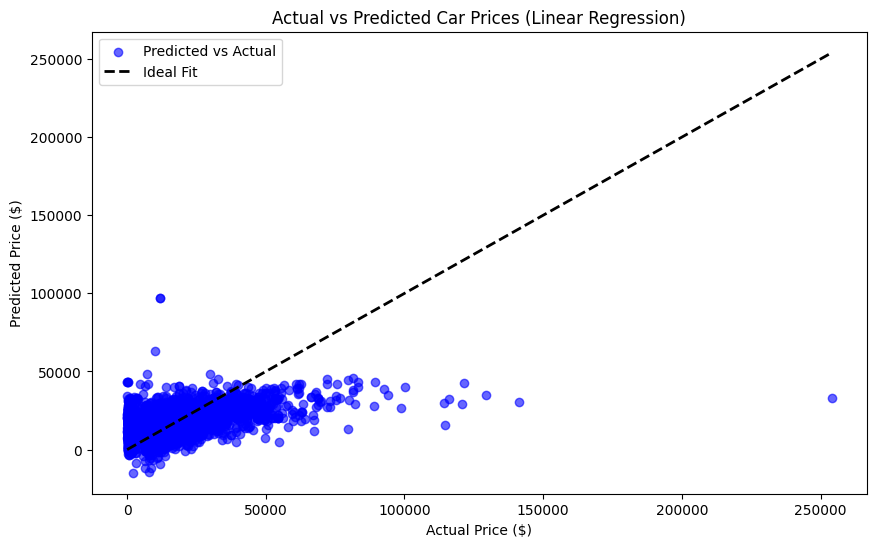


Model Coefficients:


,Feature,Coefficient
0,Levy,5196.842323
1,Prod. year,7907.776738
2,Engine volume,-569.542795
3,Mileage,51.732956
4,Cylinders,-538.297885
5,Airbags,-4269.826673
6,Leather interior,359.107014
7,Manufacturer_enc,-358.617636
8,Model_enc,317.796060
9,Category_enc,-2099.457450



Interpretation:
- Levy: A one unit increase in this feature changes the price by 5196.84 units, holding other features constant.
- Prod. year: A one unit increase in this feature changes the price by 7907.78 units, holding other features constant.
- Engine volume: A one unit increase in this feature changes the price by -569.54 units, holding other features constant.
- Mileage: A one unit increase in this feature changes the price by 51.73 units, holding other features constant.
- Cylinders: A one unit increase in this feature changes the price by -538.30 units, holding other features constant.
- Airbags: A one unit increase in this feature changes the price by -4269.83 units, holding other features constant.
- Leather interior: A one unit increase in this feature changes the price by 359.11 units, holding other features constant.
- Manufacturer_enc: A one unit increase in this feature changes the price by -358.62 units, holding other features constant.
- Model_enc: A one unit increas

In [42]:
# Make predictions
y_pred = lr_model.predict(X_test_scaled)

# 1. Find mean_absolute_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# 2. Plot regression line (scatter + line)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Predicted vs Actual', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Car Prices (Linear Regression)')
plt.legend()
plt.show()

# 3. Explain coefficients
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr_model.coef_})
print("\nModel Coefficients:")
display(coef_df)
print("\nInterpretation:")
for i, row in coef_df.iterrows():
    print(f"- {row['Feature']}: A one unit increase in this feature changes the price by {row['Coefficient']:.2f} units, holding other features constant.")

# 4. Model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"\nPerformance Metrics:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print("\nA lower MAE/RMSE and higher R² indicate a better model. Here, the model's ability to predict price depends on the quality and relevance of the features.")

## Web Integration (PHP, Django)

# To integrate this model into a web interface (PHP, Django):
# 1. Export the trained model using joblib or pickle:
#    import joblib
#    joblib.dump(lr_model, 'car_price_model.pkl')
#    joblib.dump(scaler, 'scaler.pkl')
#    joblib.dump(le_manufacturer, 'manufacturer_encoder.pkl')
#    ...
# 2. In Django:
#    - Create a form for user input (features)
#    - Load the model and encoders in a Django view
#    - Preprocess user input, scale, and predict
#    - Return the predicted price to the user
# 3. In PHP:
#    - Use a Python microservice (Flask/FastAPI) to serve predictions via HTTP API
#    - PHP frontend sends user input to the API, receives prediction
#    - Display result in the web interface
#
# See Django/Flask/FastAPI documentation for details on model deployment.

In [43]:
# Function to make predictions for new cars
def predict_car_price(levy, prod_year, engine_volume, mileage, cylinders, airbags, leather_interior, manufacturer, model, category, fuel_type, gear_box, drive_wheels, wheel, color):
    # Encode categorical variables
    manufacturer_enc = le_manufacturer.transform([manufacturer])[0]
    model_enc = le_model.transform([model])[0]
    category_enc = le_category.transform([category])[0]
    fuel_enc = le_fuel.transform([fuel_type])[0]
    gear_enc = le_gear.transform([gear_box])[0]
    drive_enc = le_drive.transform([drive_wheels])[0]
    wheel_enc = le_wheel.transform([wheel])[0]
    color_enc = le_color.transform([color])[0]

    # Create feature array
    features = np.array([[levy, prod_year, engine_volume, mileage, cylinders, airbags, leather_interior, manufacturer_enc, model_enc, category_enc, fuel_enc, gear_enc, drive_enc, wheel_enc, color_enc]])

    # Scale features
    features_scaled = scaler.transform(features)

    # Make prediction using Linear Regression
    prediction = lr_model.predict(features_scaled)[0]

    return prediction

# Example prediction
example_car = {
    'levy': 1000,
    'prod_year': 2020,
    'engine_volume': 2.0,
    'mileage': 30000,
    'cylinders': 4,
    'airbags': 8,
    'leather_interior': 1,
    'manufacturer': 'TOYOTA',
    'model': 'Camry',
    'category': 'Sedan',
    'fuel_type': 'Petrol',
    'gear_box': 'Automatic',
    'drive_wheels': 'Front',
    'wheel': 'Left wheel',
    'color': 'Black'
}

predicted_price = predict_car_price(**example_car)
print(f"Predicted price for the example car: ${predicted_price:.2f}")

# Save the model and preprocessing objects
import joblib

# Save models and encoders
joblib.dump(lr_model, 'car_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_manufacturer, 'manufacturer_encoder.pkl')
joblib.dump(le_model, 'model_encoder.pkl')
joblib.dump(le_category, 'category_encoder.pkl')
joblib.dump(le_fuel, 'fuel_encoder.pkl')
joblib.dump(le_gear, 'gear_encoder.pkl')
joblib.dump(le_drive, 'drive_encoder.pkl')
joblib.dump(le_wheel, 'wheel_encoder.pkl')
joblib.dump(le_color, 'color_encoder.pkl')

print("Model and preprocessing objects saved successfully!")

# To load and use the model later:
# lr_model = joblib.load('car_price_model.pkl')
# scaler = joblib.load('scaler.pkl')
# le_manufacturer = joblib.load('manufacturer_encoder.pkl')
# etc.

Predicted price for the example car: $29416.20
Model and preprocessing objects saved successfully!


## Improved Model: Random Forest with Log-Transformed Price

Linear Regression can predict negative prices. We fix this by:
1. **Log-transforming the target** (price) so predictions are always positive when reversed with `exp()`
2. **Using Random Forest** which handles non-linear relationships and categorical data much better

=== Random Forest (Log-Transformed Target) ===
MAE:  4174.22
RMSE: 9422.34
R²:   0.7055

=== Previous Linear Regression ===
MAE:  11091.82
RMSE: 15480.02
R²:   0.2051


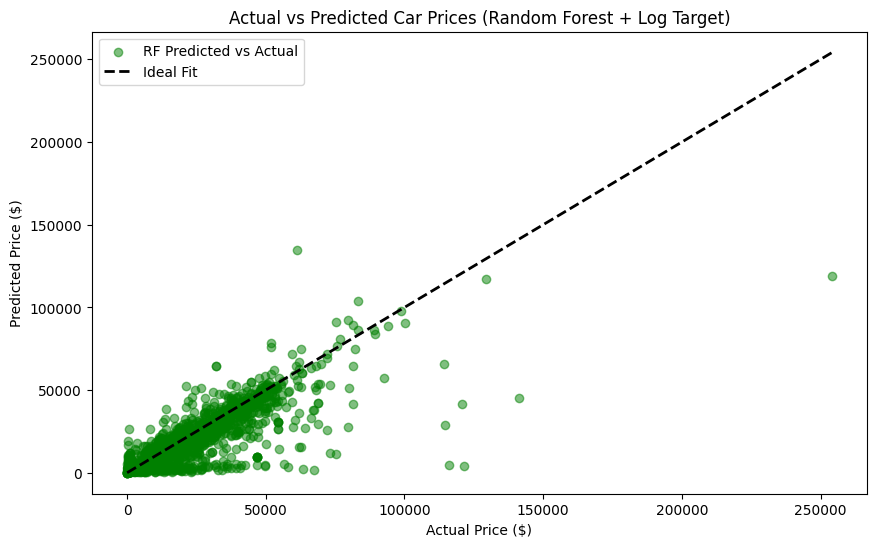

In [44]:
from sklearn.ensemble import RandomForestRegressor

# Log-transform the target to avoid negative predictions
y_log = np.log1p(y)  # log1p(x) = log(1+x), safe for 0 values

# Re-split with log-transformed target
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Random Forest doesn't need scaling, but we keep consistent preprocessing
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train2_scaled, y_train2)

# Predict and reverse the log transform
y_pred_log = rf_model.predict(X_test2_scaled)
y_pred_rf = np.expm1(y_pred_log)          # expm1 = exp(x) - 1, reverses log1p
y_test_orig = np.expm1(y_test2)            # reverse for comparison

# Metrics (on original scale)
mae_rf  = mean_absolute_error(y_test_orig, y_pred_rf)
mse_rf  = mean_squared_error(y_test_orig, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test_orig, y_pred_rf)

print("=== Random Forest (Log-Transformed Target) ===")
print(f"MAE:  {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²:   {r2_rf:.4f}")

print("\n=== Previous Linear Regression ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# Plot: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred_rf, alpha=0.5, color='green', label='RF Predicted vs Actual')
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'k--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Car Prices (Random Forest + Log Target)')
plt.legend()
plt.show()


In [45]:
# Updated prediction function using RF + log-transform (no more negative prices)
def predict_car_price_rf(levy, prod_year, engine_volume, mileage, cylinders, airbags,
                          leather_interior, manufacturer, model, category,
                          fuel_type, gear_box, drive_wheels, wheel, color):
    manufacturer_enc = le_manufacturer.transform([manufacturer])[0]
    model_enc        = le_model.transform([model])[0]
    category_enc     = le_category.transform([category])[0]
    fuel_enc         = le_fuel.transform([fuel_type])[0]
    gear_enc         = le_gear.transform([gear_box])[0]
    drive_enc        = le_drive.transform([drive_wheels])[0]
    wheel_enc        = le_wheel.transform([wheel])[0]
    color_enc        = le_color.transform([color])[0]

    feat = np.array([[levy, prod_year, engine_volume, mileage, cylinders, airbags,
                      leather_interior, manufacturer_enc, model_enc, category_enc,
                      fuel_enc, gear_enc, drive_enc, wheel_enc, color_enc]])
    feat_scaled = scaler2.transform(feat)

    log_pred = rf_model.predict(feat_scaled)[0]
    price    = np.expm1(log_pred)          # always positive
    return price

# Test with the same example car
predicted_price_rf = predict_car_price_rf(**example_car)
print(f"Linear Regression predicted: ${predicted_price:.2f}")
print(f"Random Forest predicted:     ${predicted_price_rf:.2f}")

# Save the improved model
joblib.dump(rf_model,  'car_price_rf_model.pkl')
joblib.dump(scaler2,   'scaler2.pkl')
print("Random Forest model saved!")


Linear Regression predicted: $29416.20
Random Forest predicted:     $39320.10
Random Forest model saved!


## Stacking Ensemble: Linear Regression + Random Forest → Ridge Meta-Model

Stacking trains base models (Linear Regression, Random Forest) and feeds their predictions as inputs to a meta-model (Ridge), which learns the best way to combine them.

- **Base models** use out-of-fold (cross-validated) predictions during training to avoid data leakage
- **Meta-model** (Ridge) learns how to weight each base model's output
- **Log-transformed target** is used throughout — predictions are reversed with `expm1` at the end

Training stacking model (this may take a minute)...


/Users/atabuhmarcus/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/atabuhmarcus/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/atabuhmarcus/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/atabuhmarcus/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/atabuhmarcus/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/atabuhmarcus/Library/Python/3.9/lib/python/site-packages/skle


========= Model Comparison =========
Model                                 MAE       RMSE       R²
------------------------------------------------------------
Linear Regression                11091.82   15480.02   0.2051
Random Forest (log target)        4174.22    9422.34   0.7055
Stacking (LR + RF → Ridge)        4182.20    9409.23   0.7063


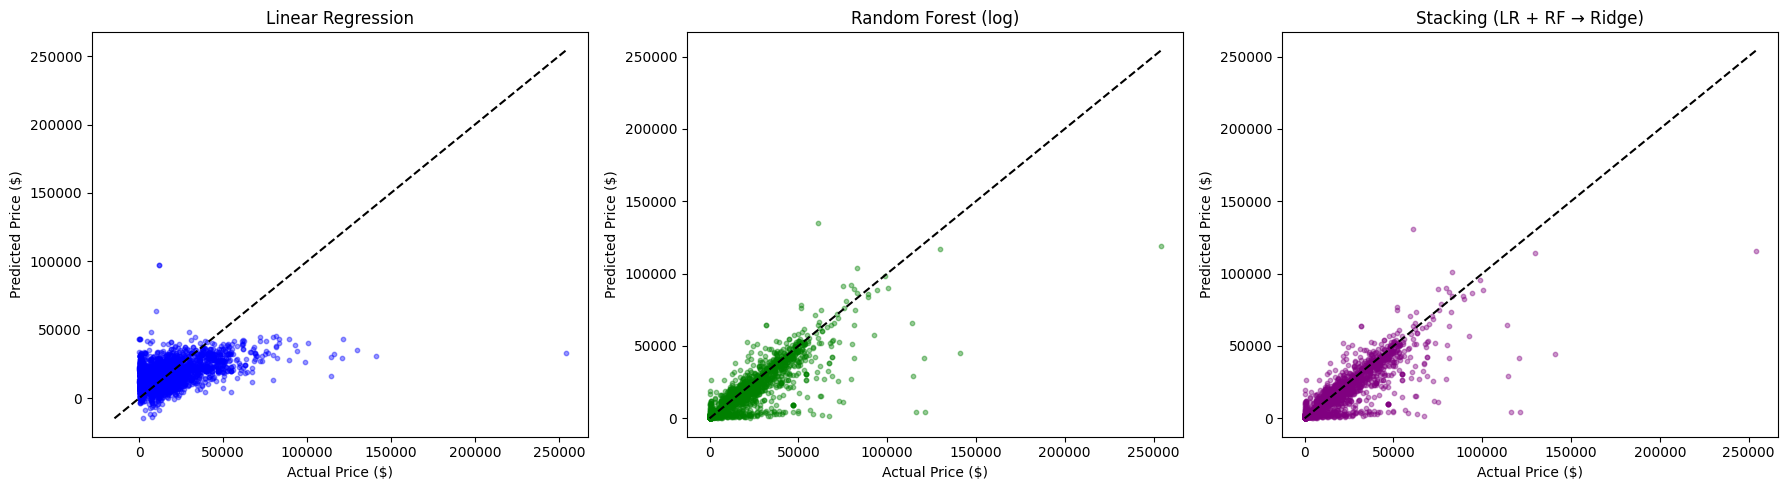

In [46]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Each base estimator gets its own scaler inside a Pipeline
# so StackingRegressor handles cross-val splitting cleanly
base_estimators = [
    ('lr',  Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])),
    ('rf',  Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])),
]

# Meta-model: Ridge regression learns to combine base model outputs
meta_model = Ridge()

stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,           # 5-fold cross-val to generate out-of-fold predictions
    n_jobs=-1,
    passthrough=False  # meta-model only sees base model predictions, not raw features
)

# Train on log-transformed target (same as RF model above)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y_log, test_size=0.2, random_state=42)

print("Training stacking model (this may take a minute)...")
stacking_model.fit(X_train3, y_train3)

# Predict and reverse log transform
y_pred_stack_log  = stacking_model.predict(X_test3)
y_pred_stack      = np.expm1(y_pred_stack_log)
y_test3_orig      = np.expm1(y_test3)

# Metrics
mae_stack  = mean_absolute_error(y_test3_orig, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test3_orig, y_pred_stack))
r2_stack   = r2_score(y_test3_orig, y_pred_stack)

# Comparison table
print("\n========= Model Comparison =========")
print(f"{'Model':<30} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("-" * 60)
print(f"{'Linear Regression':<30} {mae:>10.2f} {rmse:>10.2f} {r2:>8.4f}")
print(f"{'Random Forest (log target)':<30} {mae_rf:>10.2f} {rmse_rf:>10.2f} {r2_rf:>8.4f}")
print(f"{'Stacking (LR + RF → Ridge)':<30} {mae_stack:>10.2f} {rmse_stack:>10.2f} {r2_stack:>8.4f}")

# Plot all three side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    (y_test,       y_pred,       'Linear Regression',            'blue'),
    (y_test_orig,  y_pred_rf,    'Random Forest (log)',          'green'),
    (y_test3_orig, y_pred_stack, 'Stacking (LR + RF → Ridge)',   'purple'),
]

for ax, (y_t, y_p, title, color) in zip(axes, pairs):
    ax.scatter(y_t, y_p, alpha=0.4, color=color, s=10)
    lim = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]
    ax.plot(lim, lim, 'k--', lw=1.5)
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.set_title(title)

plt.tight_layout()
plt.show()


In [47]:
# Prediction function for the stacking model
def predict_car_price_stack(levy, prod_year, engine_volume, mileage, cylinders, airbags,
                             leather_interior, manufacturer, model, category,
                             fuel_type, gear_box, drive_wheels, wheel, color):
    manufacturer_enc = le_manufacturer.transform([manufacturer])[0]
    model_enc        = le_model.transform([model])[0]
    category_enc     = le_category.transform([category])[0]
    fuel_enc         = le_fuel.transform([fuel_type])[0]
    gear_enc         = le_gear.transform([gear_box])[0]
    drive_enc        = le_drive.transform([drive_wheels])[0]
    wheel_enc        = le_wheel.transform([wheel])[0]
    color_enc        = le_color.transform([color])[0]

    feat = np.array([[levy, prod_year, engine_volume, mileage, cylinders, airbags,
                      leather_interior, manufacturer_enc, model_enc, category_enc,
                      fuel_enc, gear_enc, drive_enc, wheel_enc, color_enc]])

    # Stacking pipeline has its own scalers inside — no external scaling needed
    log_pred = stacking_model.predict(feat)[0]
    return np.expm1(log_pred)

# Test with the same example car
price_stack = predict_car_price_stack(**example_car)
print(f"Linear Regression predicted: ${predicted_price:.2f}")
print(f"Random Forest predicted:     ${predicted_price_rf:.2f}")
print(f"Stacking model predicted:    ${price_stack:.2f}")

# Save
joblib.dump(stacking_model, 'car_price_stack_model.pkl')
print("\nStacking model saved to car_price_stack_model.pkl")


Linear Regression predicted: $29416.20
Random Forest predicted:     $39320.10
Stacking model predicted:    $39074.09

Stacking model saved to car_price_stack_model.pkl


## Final Model Comparison Summary

In [ ]:
print("=" * 62)
print(f"{'Model':<30} {'MAE':>8} {'RMSE':>10} {'R²':>8}")
print("=" * 62)
print(f"{'Linear Regression':<30} {mae:>8.2f} {rmse:>10.2f} {r2:>8.4f}")
print(f"{'Random Forest (log target)':<30} {mae_rf:>8.2f} {rmse_rf:>10.2f} {r2_rf:>8.4f}")
print(f"{'Stacking (LR + RF → Ridge)':<30} {mae_stack:>8.2f} {rmse_stack:>10.2f} {r2_stack:>8.4f}")
print("=" * 62)

# Best model
models = {
    'Linear Regression': r2,
    'Random Forest':     r2_rf,
    'Stacking':          r2_stack,
}
best = max(models, key=models.get)
print(f"\nBest model by R²: {best} ({models[best]:.4f})")

# Example car predictions from all three models
print("\n--- Example Car Prediction ---")
print(f"Linear Regression: ${predicted_price:.2f}")
print(f"Random Forest:     ${predicted_price_rf:.2f}")
print(f"Stacking:          ${price_stack:.2f}")

# Bar chart comparison of metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

model_names  = ['Linear\nRegression', 'Random\nForest', 'Stacking\n(LR+RF→Ridge)']
mae_vals     = [mae,  mae_rf,   mae_stack]
rmse_vals    = [rmse, rmse_rf,  rmse_stack]
r2_vals      = [r2,   r2_rf,    r2_stack]
colors       = ['steelblue', 'seagreen', 'mediumpurple']

for ax, vals, ylabel, title in [
    (axes[0], mae_vals,  'MAE ($)',  'Mean Absolute Error (lower = better)'),
    (axes[1], rmse_vals, 'RMSE ($)', 'Root Mean Squared Error (lower = better)'),
    (axes[2], r2_vals,   'R²',       'R² Score (higher = better)'),
]:
    bars = ax.bar(model_names, vals, color=colors)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
